# Netflix Movies and TV Shows - Exploratory Data Analysis (EDA)


This project focuses on analyzing the Netflix Movies and TV Shows dataset using Python libraries such as pandas, matplotlib, and seaborn.

The project includes:
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Insight Extraction

# 1. Import Libraries

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

### Notes

- pandas → used for data manipulation and analysis
- numpy → used for numerical operations
- matplotlib → used for creating visualizations
- seaborn → used for advanced statistical plots

# 2. Load Dataset

In [54]:
df= pd.read_csv('netflix_titles.csv')

# 3. Understanding the Dataset

In [55]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Notes

`head()` displays the first 5 rows of the dataset.

In [56]:
df.shape

(8807, 12)

### Notes

`shape` shows the number of rows and columns in the dataset.

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Notes

`info()` provides information about:
- column names
- data types
- missing values

In [58]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

### Notes

`dtypes` displays the data type of each column in the dataset.

In [59]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### Notes

`describe()` provides statistical summaries for numerical columns.

# 4. Data Cleaning

## Checking Missing Values

In [60]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Notes

The dataset contains missing values in several columns such as:
- director
- cast
- country
- date_added
- rating
- duration

The `director` column contains the highest number of missing values.

## Handling Missing Values

In [61]:
df['director'] = df['director'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Available')
df['duration'] = df['duration'].fillna('Unknown')

### Notes

Missing categorical values were replaced with labels such as 'Unknown' and 'Not Available' to preserve the dataset and avoid dropping rows.

In [62]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

### Notes

A few missing values still remain in the `date_added` column after converting it to datetime format because some values could not be parsed as valid dates.

## Converting Date Column

In [63]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')

### Notes

The `date_added` column was converted into datetime format to make date analysis easier.

## Feature Engineering

In [64]:
df['release_month']=df['date_added'].dt.month_name()

In [65]:
df['release_day']=df['date_added'].dt.day

### Notes

New columns were created from the `date_added` column to extract useful date information such as month and day.

In [66]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,release_month,release_day
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,25.0
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,24.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,24.0
3,s4,TV Show,Jailbirds New Orleans,Not Available,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,24.0
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,24.0


### Notes

The dataset was displayed again to verify that the new columns were added successfully.

In [67]:
df.dtypes

show_id                  object
type                     object
title                    object
director                 object
cast                     object
country                  object
date_added       datetime64[ns]
release_year              int64
rating                   object
duration                 object
listed_in                object
description              object
release_month            object
release_day             float64
dtype: object

### Notes

The dataset was checked again to verify the newly created columns and their data types.

In [68]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       98
release_year      0
rating            0
duration          0
listed_in         0
description       0
release_month    98
release_day      98
dtype: int64

### Notes

The remaining missing values in `release_month` and `release_day` are related to missing values in the `date_added` column.

In [69]:
df['release_month']=df['release_month'].fillna('Unknown')
df['release_day']=df['release_day'].fillna(0)

### Notes

Missing values in `release_month` were replaced with 'Unknown', while missing values in `release_day` were replaced with 0.

In [70]:
df['release_day']=df['release_day'].astype('int')

### Notes

The `release_day` column was converted into integer format after handling missing values.

In [71]:
df.dtypes

show_id                  object
type                     object
title                    object
director                 object
cast                     object
country                  object
date_added       datetime64[ns]
release_year              int64
rating                   object
duration                 object
listed_in                object
description              object
release_month            object
release_day               int64
dtype: object

### Notes

The data types were verified to ensure that the new columns were created and formatted correctly.

## Dropping Unnecessary Columns

In [72]:
df= df.drop(['date_added'],axis=1)

### Notes

The `date_added` column was removed after extracting useful date features from it.

In [73]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,release_month,release_day
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,25
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,24
3,s4,TV Show,Jailbirds New Orleans,Not Available,Unknown,Unknown,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,24
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,24


### Notes

The dataset was displayed again to verify the final structure after data cleaning and feature engineering.

In [74]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'release_month', 'release_day'],
      dtype='object')

### Notes

The column names were displayed before reordering the dataset columns.

## Reordering Columns

In [75]:
df=df[['show_id', 'type', 'title', 'director', 'cast', 'country', 'release_year','release_month', 'release_day', 'rating', 'duration', 'listed_in', 'description']]

### Notes

The columns were reordered to improve the structure and readability of the dataset.

In [76]:
df.head()

,show_id,type,title,director,cast,country,release_year,release_month,release_day,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,September,25,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,September,24,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021,September,24,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Not Available,Unknown,Unknown,2021,September,24,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,September,24,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Notes

The dataset was displayed again to verify the new column order and final structure.

In [77]:
df.duplicated().sum()

np.int64(0)

### Notes

The dataset was checked for duplicate rows, and no duplicates were found.

# 5. Exploratory Data Analysis (EDA)

## Question 1: Movies vs TV Shows

In [78]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

### Insight

Movies make up the majority of Netflix content, while TV Shows represent a smaller portion of the dataset.

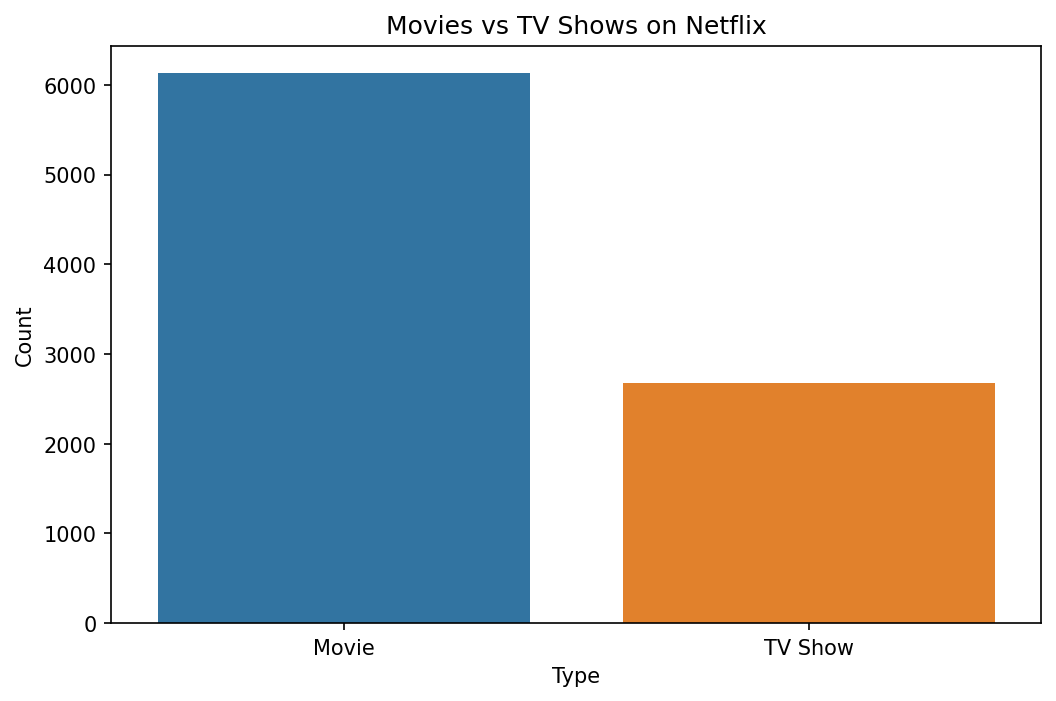

In [79]:
plt.figure(figsize=(8,5),dpi=150)
sns.countplot(data = df, x='type',hue='type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Movies vs TV Shows on Netflix')
plt.show()

## Question 2: Top Countries Producing Netflix Content

In [80]:
df['country'].value_counts()

country
United States                             2818
India                                      972
Unknown                                    831
United Kingdom                             419
Japan                                      245
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 749, dtype: int64

### Insight

The United States has the highest amount of Netflix content, followed by India and the United Kingdom.

In [81]:
df1=df['country'].value_counts().head(5)

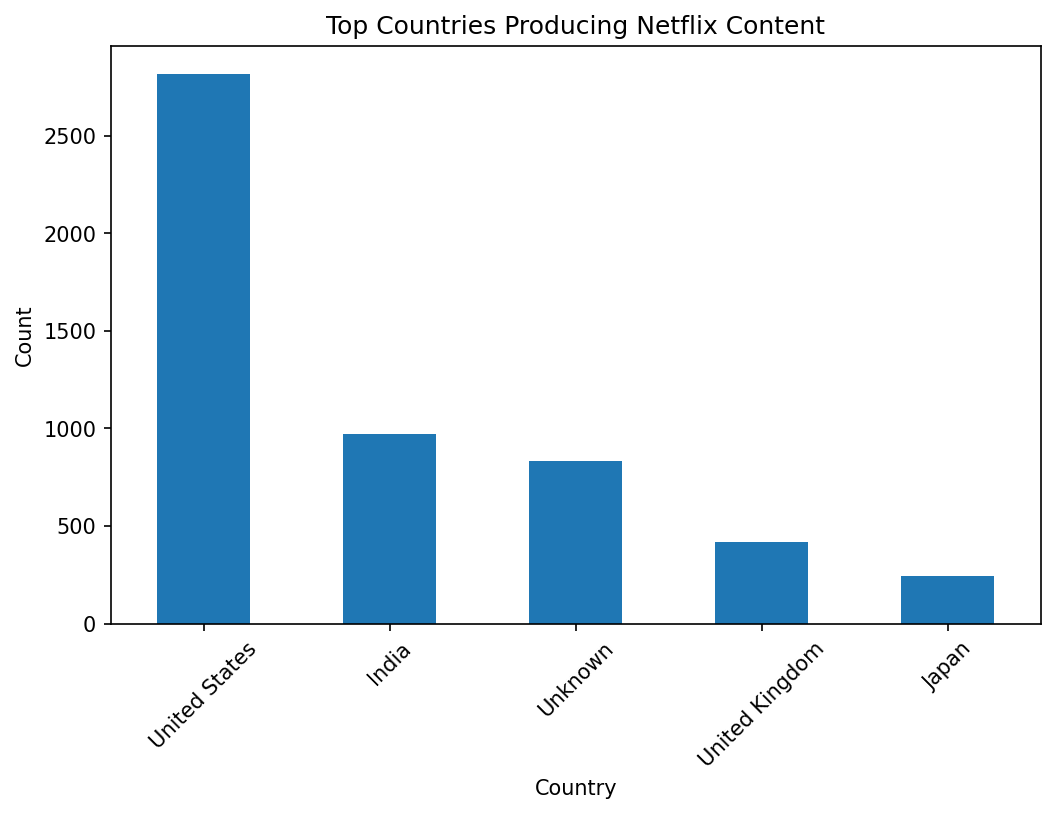

In [82]:
plt.figure(figsize=(8,5),dpi=150)
df1.plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top Countries Producing Netflix Content')
plt.xticks(rotation = 45)
plt.show()

### Insight

The United States is the leading producer of Netflix content in the dataset.

## Question 3: Most Common Ratings on Netflix

In [83]:
df['rating'].value_counts()

rating
TV-MA            3207
TV-14            2160
TV-PG             863
R                 799
PG-13             490
TV-Y7             334
TV-Y              307
PG                287
TV-G              220
NR                 80
G                  41
TV-Y7-FV            6
Not Available       4
NC-17               3
UR                  3
74 min              1
84 min              1
66 min              1
Name: count, dtype: int64

In [84]:
df['rating'] = df['rating'].replace(['74 min', '84 min', '66 min'], 'Unknown')

### Notes

Incorrect duration values found in the `rating` column were replaced with 'Unknown' during the analysis process.

In [85]:
df_rating=df['rating'].value_counts().head(5)

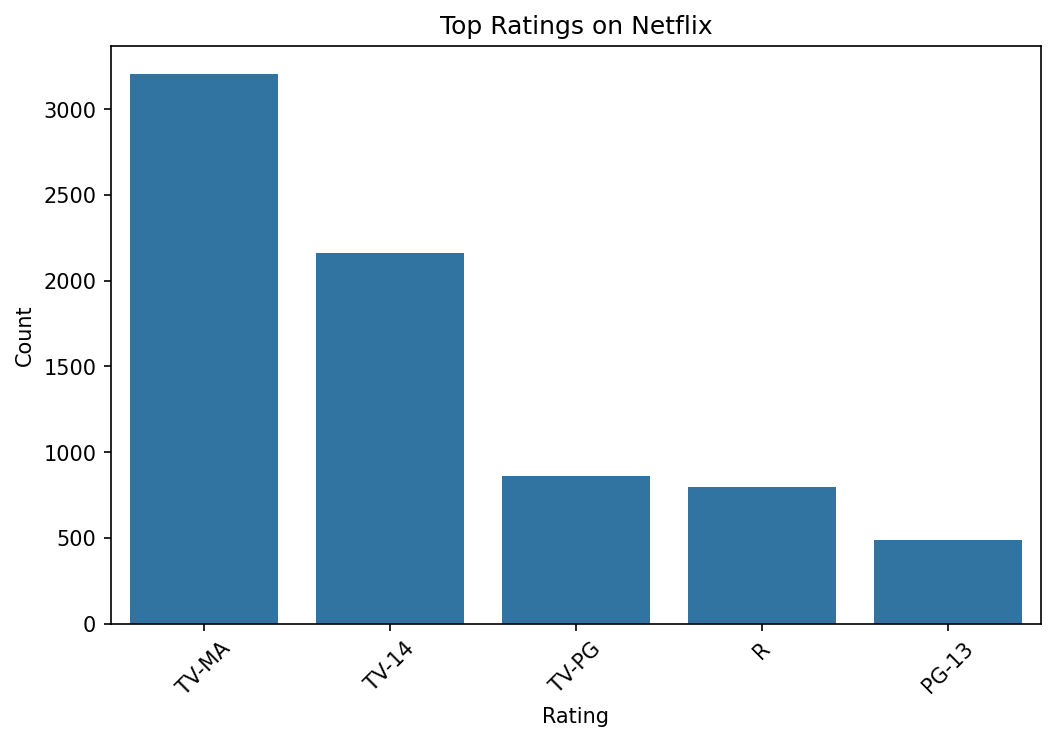

In [86]:
plt.figure(figsize=(8,5),dpi=150)
sns.barplot(
    x=df_rating.index,
    y=df_rating.values
)

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Top Ratings on Netflix')
plt.xticks(rotation=45)

plt.show()

### Insight

TV-MA and TV-14 are the most common ratings on Netflix.

## Question 4: Netflix Content Released by Year

In [87]:
df['release_year'].value_counts()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: count, Length: 74, dtype: int64

### Notes

The number of Netflix titles released each year was analyzed to understand content trends over time.

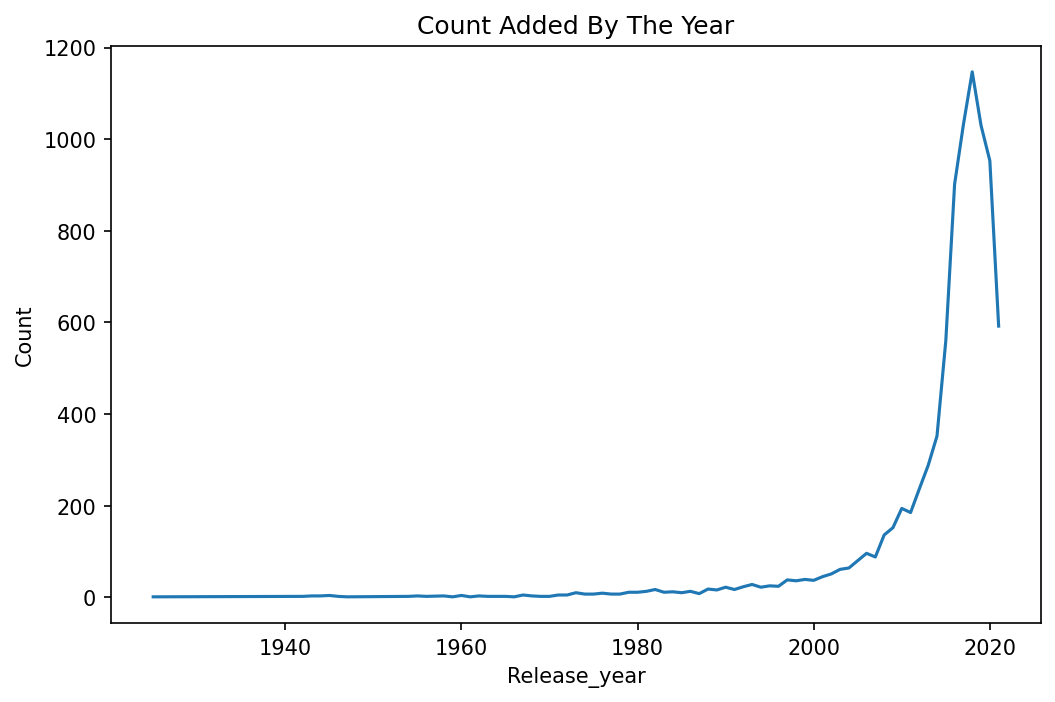

In [88]:
Contant_added_by_the_Year=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,5),dpi=150)
sns.lineplot(
    x=Contant_added_by_the_Year.index,
    y=Contant_added_by_the_Year.values
)
plt.xlabel('Release_year')
plt.ylabel('Count')
plt.title('Count Added By The Year')
plt.show()

### Insight

Netflix content releases remained relatively low for many years, then increased rapidly after 2010 and peaked around 2018–2019.

## Question 5: Netflix Content Added by Month

In [89]:
df['release_month'].value_counts().head(12)


release_month
July         819
December     797
September    765
April        759
October      755
August       749
March        734
January      727
June         724
November     697
May          626
February     557
Name: count, dtype: int64

### Insight

Netflix tends to add more content during months such as July and December, whereas February shows the lowest number of additions.

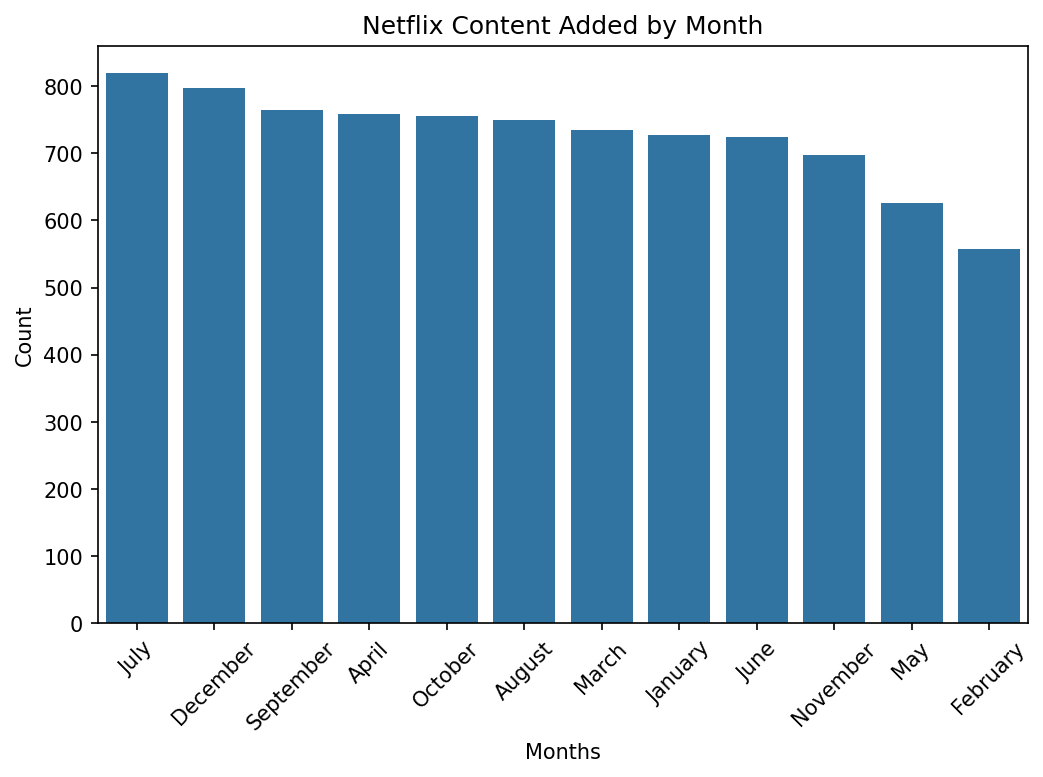

In [90]:
top_months=df['release_month'].value_counts().head(12)
plt.figure(figsize=(8,5),dpi=150)
sns.barplot(
    x=top_months.index,
    y=top_months.values
)
plt.xlabel('Months')
plt.ylabel('Count')
plt.title('Netflix Content Added by Month')
plt.xticks(rotation=45)
plt.show()

### Insight

July and December contain the highest number of Netflix content additions, while February contains the lowest.

## Question 6: Most Common Genres on Netflix

In [91]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

### Insight

Drama and International Movies are among the most common genres on Netflix.

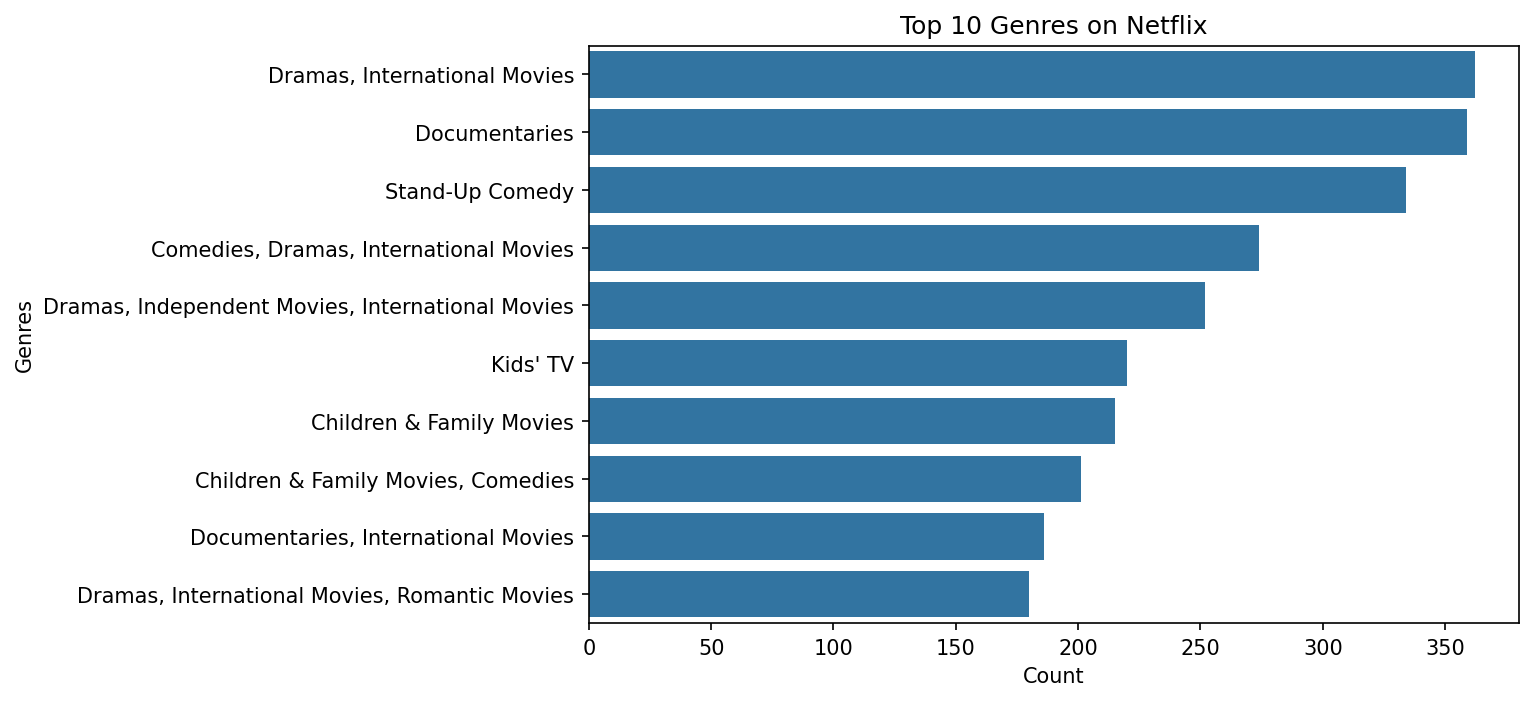

In [92]:
top_genre=df['listed_in'].value_counts().head(10)
plt.figure(figsize=(8,5),dpi=150)
sns.barplot(
    x=top_genre.values,
    y=top_genre.index
)
plt.xlabel('Count')
plt.ylabel('Genres')
plt.title('Top 10 Genres on Netflix')
plt.show()

### Insight

Drama and International Movies are among the most common genres available on Netflix.

## Question 7: TV Show Seasons Analysis

In [93]:
tv_shows=df[df['type']=='TV Show']
tv_shows['duration'].value_counts().head(5)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
4 Seasons      95
5 Seasons      65
Name: count, dtype: int64

### Notes

The dataset was filtered to include only TV Shows so the season analysis would not be mixed with movie durations.

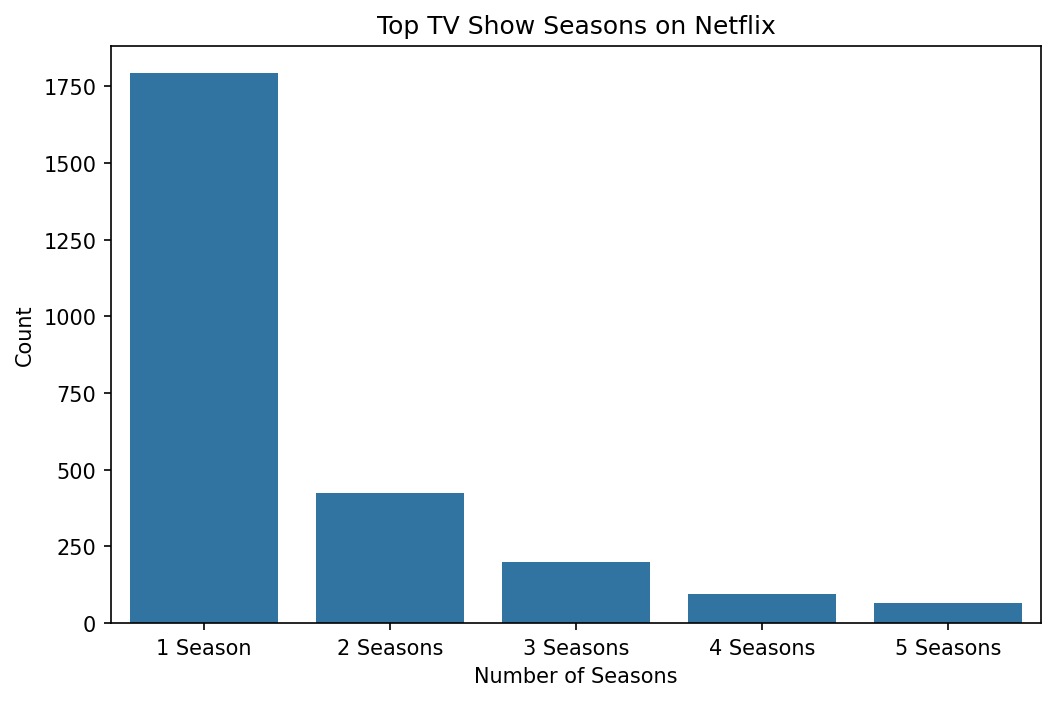

In [94]:
top_tv_shows = tv_shows['duration'].value_counts().head(5)
plt.figure(figsize=(8,5),dpi=150)
sns.barplot(
    x=top_tv_shows.index,
    y=top_tv_shows.values
)
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.title('Top TV Show Seasons on Netflix')
plt.show()

### Insight

Most TV Shows on Netflix contain only one season, while shows with multiple seasons are less common.

## Question 8: Most Common Movie Durations

In [95]:
movies=df[df['type']=='Movie']
movies['duration'].value_counts().head(5)

duration
90 min    152
94 min    146
93 min    146
97 min    146
91 min    144
Name: count, dtype: int64

### Notes

The dataset was filtered to include only Movies so movie durations could be analyzed separately from TV Show seasons.

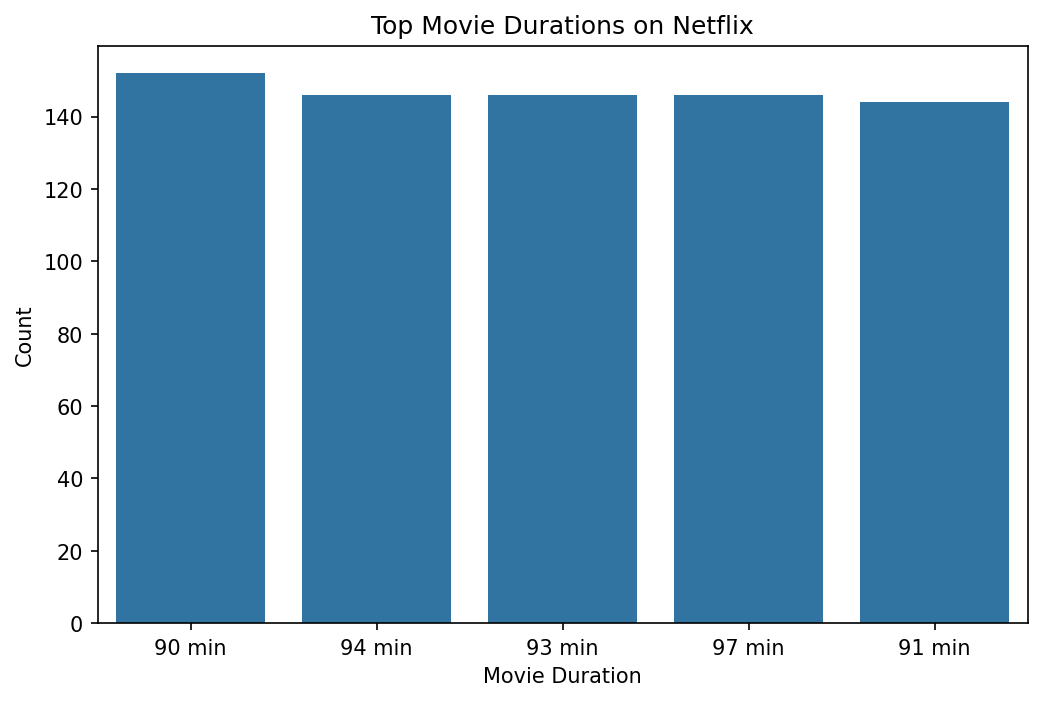

In [96]:
top_Movies = movies['duration'].value_counts().head(5)
plt.figure(figsize=(8,5),dpi=150)
sns.barplot(
    x=top_Movies.index,
    y=top_Movies.values
)
plt.xlabel('Movie Duration')
plt.ylabel('Count')
plt.title('Top Movie Durations on Netflix')
plt.show()

### Insight

Movies with durations between 90 and 97 minutes are the most common on Netflix.

# Final Conclusion

### Summary of Findings

* Netflix contains more Movies than TV Shows
* The United States produces the highest amount of Netflix content
* Drama and International Movies are among the most common genres
* Most TV Shows contain only one season
* Movies with durations between 90 and 97 minutes are very common on Netflix
* TV-MA and TV-14 are the most frequent ratings

### Skills Demonstrated

* Data Cleaning
* Handling Missing Values
* Feature Engineering
* Data Visualization
* Exploratory Data Analysis (EDA)
* Insight Extraction